In [1]:
import os

max_depth = 4
base_depth = "/kaggle/input".count(os.sep)
for dirpath, dirnames, filenames in os.walk("/kaggle/input"):
    depth = dirpath.count(os.sep) - base_depth
    if depth > max_depth:
        dirnames[:] = []
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(dirpath) or dirpath}/  [{len(filenames)} files]  {filenames[:2]}")

input/  [0 files]  []
  datasets/  [0 files]  []
    hamdallak/  [0 files]  []
      the-iqothnccd-lung-cancer-dataset/  [0 files]  []
        The IQ-OTHNCCD lung cancer dataset/  [1 files]  ['IQ-OTH_NCCD lung cancer dataset.txt']


In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

TARGET_CLASSES = ["normal", "benign", "malignant"]
CLASS_TO_IDX = {c: i for i, c in enumerate(TARGET_CLASSES)}
NUM_CLASSES = len(TARGET_CLASSES)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 35
LEARNING_RATE = 5e-4
EARLY_STOP_PATIENCE = 5

In [3]:
def fuzzy_map_class(folder_name):
    n = folder_name.lower()
    if "normal" in n:
        return "normal"
    if "benign" in n or "bengin" in n:
        return "benign"
    if "malignant" in n:
        return "malignant"
    return None

records = []
found_dirs = []
for dirpath, dirnames, filenames in os.walk("/kaggle/input"):
    label = fuzzy_map_class(os.path.basename(dirpath))
    if label is None:
        continue
    image_files = [f for f in filenames if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
    if not image_files:
        continue
    found_dirs.append((dirpath, label, len(image_files)))
    for fname in image_files:
        records.append({"filepath": os.path.join(dirpath, fname), "label": label})

print("Matched folders:")
for d, l, n in found_dirs:
    print(f"  {d}  ->  {l}  ({n} images)")

full_pool = pd.DataFrame(records)
assert len(full_pool) > 0, "No images found -- make sure the IQ-OTH/NCCD dataset is attached under /kaggle/input"

print("\nPooled total:", len(full_pool))
print(full_pool["label"].value_counts())

Matched folders:
  /kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases  ->  normal  (416 images)
  /kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Bengin cases  ->  benign  (120 images)
  /kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Malignant cases  ->  malignant  (561 images)

Pooled total: 1097
label
malignant    561
normal       416
benign       120
Name: count, dtype: int64


In [4]:
full_pool = full_pool.sample(frac=1.0, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    full_pool, train_size=0.60, stratify=full_pool["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, train_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df), " Val size:", len(val_df), " Test size:", len(test_df))
print("\nTrain class balance:\n", train_df["label"].value_counts())
print("\nVal class balance:\n", val_df["label"].value_counts())
print("\nTest class balance:\n", test_df["label"].value_counts())

Train size: 658  Val size: 219  Test size: 220

Train class balance:
 label
malignant    336
normal       250
benign        72
Name: count, dtype: int64

Val class balance:
 label
malignant    112
normal        83
benign        24
Name: count, dtype: int64

Test class balance:
 label
malignant    113
normal        83
benign        24
Name: count, dtype: int64


In [5]:
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = datagen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="categorical",
    classes=TARGET_CLASSES, batch_size=BATCH_SIZE, shuffle=True, seed=42
)
val_gen = datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="categorical",
    classes=TARGET_CLASSES, batch_size=BATCH_SIZE, shuffle=False
)
test_gen = datagen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="categorical",
    classes=TARGET_CLASSES, batch_size=BATCH_SIZE, shuffle=False
)
print("class_indices:", train_gen.class_indices)

Found 658 validated image filenames belonging to 3 classes.
Found 219 validated image filenames belonging to 3 classes.
Found 220 validated image filenames belonging to 3 classes.
class_indices: {'normal': 0, 'benign': 1, 'malignant': 2}


In [6]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3),
    pooling="avg"
)
base_model.trainable = True  # 100% fine-tuning -- entire backbone trainable from epoch 1

output_layer = Dense(NUM_CLASSES, activation="softmax")(base_model.output)
model = Model(inputs=base_model.input, outputs=output_layer)
model.summary()

model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=LEARNING_RATE),
    metrics=["accuracy"]
)

I0000 00:00:1790593477.071095      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790593477.077307      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 4,011,391 (15.30 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [7]:
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph

def get_flops(keras_model, batch_size=1):
    """Forward-pass FLOPs for `keras_model` at the given batch size, via TF's graph profiler."""
    input_shape = [batch_size] + list(keras_model.input.shape[1:])
    concrete_func = tf.function(lambda x: keras_model(x)).get_concrete_function(
        tf.TensorSpec(input_shape, keras_model.input.dtype)
    )
    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(concrete_func)
    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name="")
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd="op", options=opts)
    return flops.total_float_ops

# --- Trainable-vs-frozen parameter split, read directly from the model (not assumed) ---
trainable_param_count = sum(int(tf.size(w)) for w in model.trainable_weights)
total_param_count = sum(int(tf.size(w)) for w in model.weights)
trainable_fraction = trainable_param_count / total_param_count

TRAINING_FLOPS_MULTIPLIER = 1 + 2 * trainable_fraction  # 1x forward + up to 2x backward, scaled by how much of the model is actually trainable

print(f"Trainable params: {trainable_param_count:,} / {total_param_count:,} total  (trainable_fraction={trainable_fraction:.4f})")
print(f"Derived training FLOPs multiplier: {TRAINING_FLOPS_MULTIPLIER:.4f}x forward\n")

# --- Forward pass ---
flops_per_image_fwd = get_flops(model, batch_size=1)
flops_per_batch_fwd = get_flops(model, batch_size=BATCH_SIZE)

# --- Fine-tuning (forward + backward) ---
flops_per_image_train = flops_per_image_fwd * TRAINING_FLOPS_MULTIPLIER
flops_per_batch_train = flops_per_batch_fwd * TRAINING_FLOPS_MULTIPLIER

steps_per_epoch = len(train_df) // BATCH_SIZE
flops_per_epoch_train = flops_per_batch_train * steps_per_epoch
flops_full_run_train = flops_per_epoch_train * EPOCHS  # upper bound -- ignores early stopping cutting epochs short

print("=== Forward pass ===")
print(f"Per image:  {flops_per_image_fwd:,} FLOPs  (~{flops_per_image_fwd/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_fwd:,} FLOPs  (~{flops_per_batch_fwd/1e9:.3f} GFLOPs)")

print(f"\n=== Fine-tuning (forward + backward, ~{TRAINING_FLOPS_MULTIPLIER:.2f}x forward) ===")
print(f"Per image:  {flops_per_image_train:,} FLOPs  (~{flops_per_image_train/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_train:,} FLOPs  (~{flops_per_batch_train/1e9:.3f} GFLOPs)")
print(f"\nSteps per epoch: {steps_per_epoch}  (train set size {len(train_df)} / batch size {BATCH_SIZE})")
print(f"Per epoch:  {flops_per_epoch_train:,} FLOPs  (~{flops_per_epoch_train/1e12:.3f} TFLOPs)")
print(f"Full {EPOCHS}-epoch run (upper bound, no early stopping):  {flops_full_run_train:,} FLOPs  (~{flops_full_run_train/1e15:.3f} PFLOPs)")

Trainable params: 4,011,391 / 4,053,414 total  (trainable_fraction=0.9896)
Derived training FLOPs multiplier: 2.9793x forward



I0000 00:00:1790593481.661720      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1790593481.661912      58 single_machine.cc:376] Starting new session
I0000 00:00:1790593481.676953      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790593481.678517      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation ker

I0000 00:00:1790593485.062847      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1790593485.063033      58 single_machine.cc:376] Starting new session
I0000 00:00:1790593485.078006      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790593485.079605      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

In [8]:
callbacks = [
    ModelCheckpoint("best_effnetb0_iqothnccd_224.keras", monitor="val_accuracy", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_loss", patience=EARLY_STOP_PATIENCE, restore_best_weights=True, verbose=1),
]

In [9]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/35


2026-09-28 11:05:36.403034: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 11:05:36.543699: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 11:05:36.876694: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 11:05:37.019733: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 11:05:37.809224: E external/local_xla/xla/stream_

25/42 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 0.7233 - loss: 0.6242

2026-09-28 11:06:22.890663: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 11:06:23.025092: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 11:06:23.346155: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 11:06:23.488661: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 11:06:24.274972: E external/local_xla/xla/stream_

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7633 - loss: 0.5485

2026-09-28 11:07:08.854048: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 11:07:08.992134: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 11:07:09.312893: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 11:07:09.455045: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 11:07:10.258158: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from None to 0.85845, saving model to best_effnetb0_iqothnccd_224.keras

Epoch 1: finished saving model to best_effnetb0_iqothnccd_224.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.8389 - loss: 0.4063 - val_accuracy: 0.8584 - val_loss: 0.3323
Epoch 2/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9526 - loss: 0.1374
Epoch 2: val_accuracy improved from 0.85845 to 0.90868, saving model to best_effnetb0_iqothnccd_224.keras

Epoch 2: finished saving model to best_effnetb0_iqothnccd_224.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - accuracy: 0.9590 - loss: 0.1178 - val_accuracy: 0.9087 - val_loss: 0.3162
Epoch 3/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9488 - loss: 0.1425
Epoch 3: val_accuracy improved from 0.90868 to 0.95434, saving model to best_effnetb0_iqothnccd_224.keras

Epoch 3: finished saving model to best_effnetb0_iqothnccd_224.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - accuracy: 0.9453 - loss: 0.1531

## 9. Plot train/val loss + accuracy

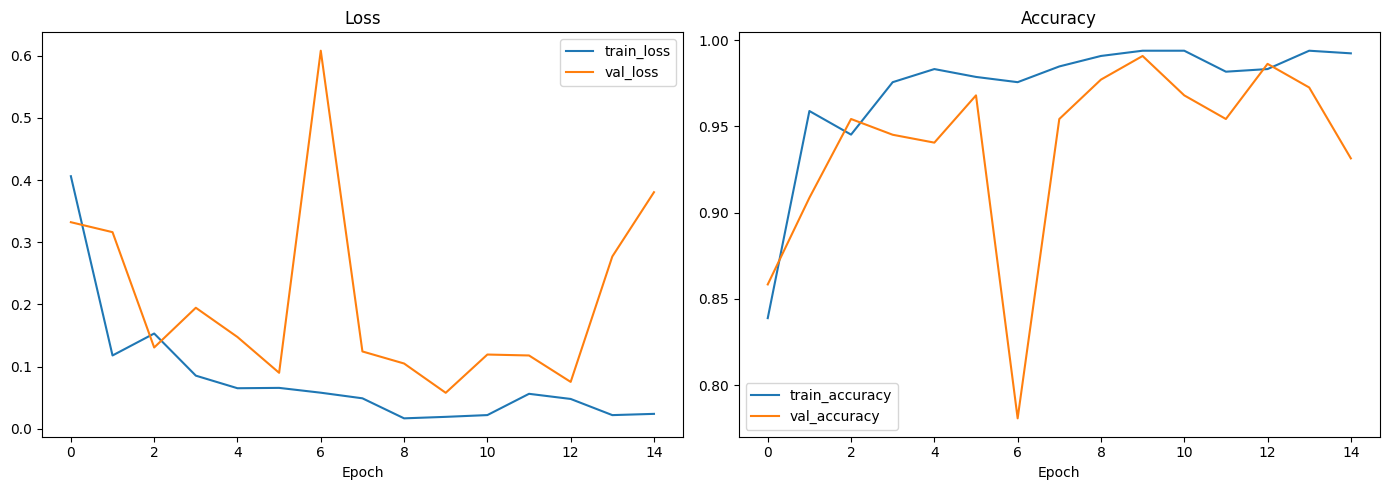

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="train_loss")
axes[0].plot(history.history["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train_accuracy")
axes[1].plot(history.history["val_accuracy"], label="val_accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_effnetb0_iqothnccd_224.png", dpi=150)
plt.show()

13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9684 - loss: 0.0671

2026-09-28 11:08:41.318899: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 11:08:41.457198: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 11:08:41.785863: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 11:08:41.928008: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 11:08:42.726113: E external/local_xla/xla/stream_

14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 969ms/step - accuracy: 0.9727 - loss: 0.0704
Test loss: 0.0704  Test accuracy: 0.9727

Classification Report:
              precision    recall  f1-score   support

      normal     1.0000    0.9398    0.9689        83
      benign     0.8519    0.9583    0.9020        24
   malignant     0.9826    1.0000    0.9912       113

    accuracy                         0.9727       220
   macro avg     0.9448    0.9660    0.9540       220
weighted avg     0.9749    0.9727    0.9731       220

Test macro F1: 0.9540

Prediction distribution:
malignant    115
normal        78
benign        27
Name: count, dtype: int64


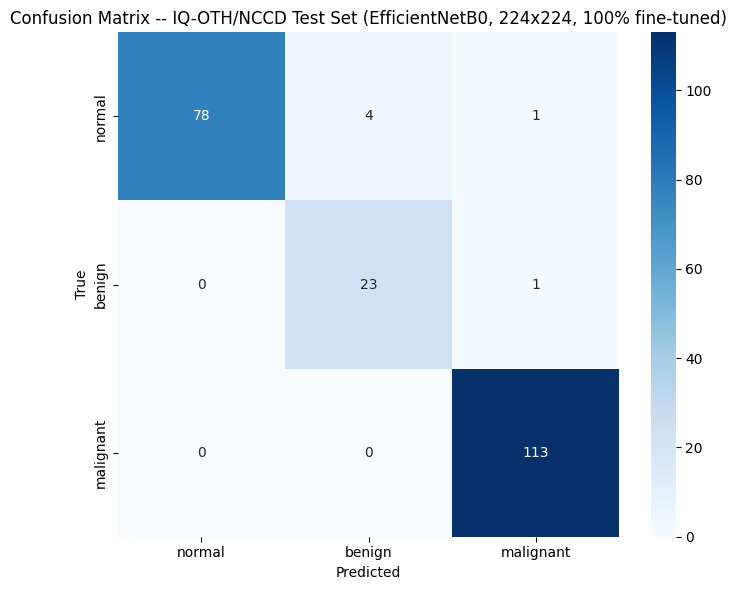


EfficientNetB0 (IQ-OTH/NCCD, 224x224) test accuracy: 97.27%


In [11]:
best_model = tf.keras.models.load_model("best_effnetb0_iqothnccd_224.keras")

test_gen.reset()
test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)
print(f"Test loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}")

test_gen.reset()
y_pred_probs = best_model.predict(test_gen, verbose=0)
y_pred_idx = np.argmax(y_pred_probs, axis=1)
y_true_idx = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true_idx, y_pred_idx, target_names=TARGET_CLASSES, digits=4))

test_macro_f1 = f1_score(y_true_idx, y_pred_idx, average="macro")
print(f"Test macro F1: {test_macro_f1:.4f}")

print("\nPrediction distribution:")
print(pd.Series(y_pred_idx).map({i: c for i, c in enumerate(TARGET_CLASSES)}).value_counts())

cm = confusion_matrix(y_true_idx, y_pred_idx)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix -- IQ-OTH/NCCD Test Set (EfficientNetB0, 224x224, 100% fine-tuned)")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_effnetb0_iqothnccd_224.png", dpi=150)
plt.show()

print(f"\nEfficientNetB0 (IQ-OTH/NCCD, 224x224) test accuracy: {test_acc*100:.2f}%")